In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes')
)

X = data["data"]        # text documents
y = data["target"]      # class labels

In [3]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.7
)

X_vectors = vectorizer.fit_transform(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectors, y, test_size=0.3, random_state=42,stratify=y
)

In [5]:
model = MultinomialNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [6]:
y_pred = model.predict(X_test)

Accuracy: 0.7210824195259993

Confusion Matrix:



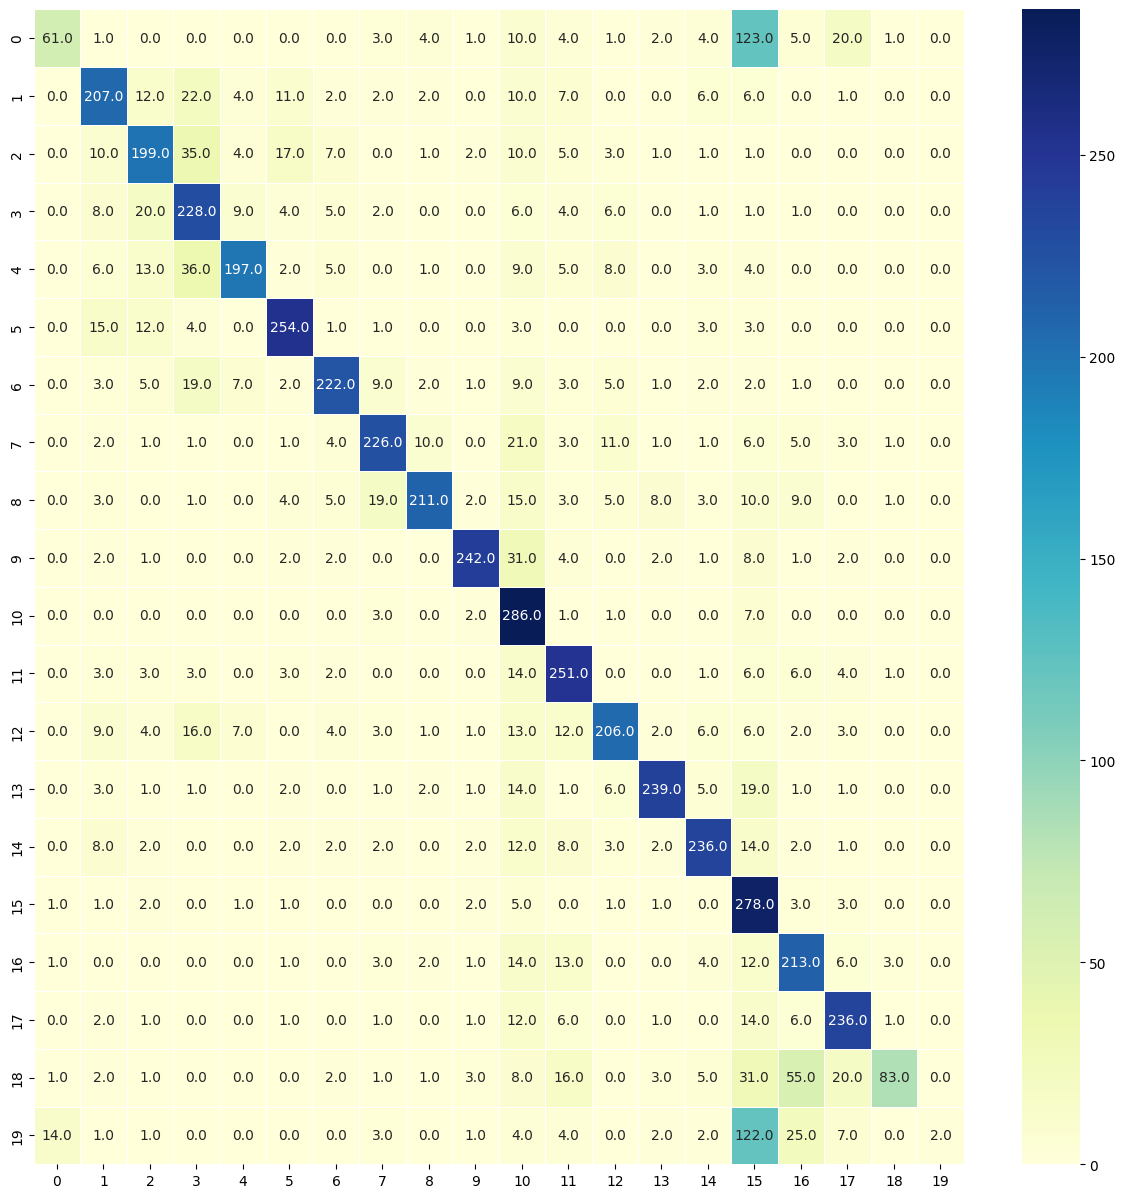


Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.25      0.38       240
           1       0.72      0.71      0.72       292
           2       0.72      0.67      0.69       296
           3       0.62      0.77      0.69       295
           4       0.86      0.68      0.76       289
           5       0.83      0.86      0.84       296
           6       0.84      0.76      0.80       293
           7       0.81      0.76      0.78       297
           8       0.89      0.71      0.79       299
           9       0.92      0.81      0.86       298
          10       0.57      0.95      0.71       300
          11       0.72      0.85      0.78       297
          12       0.80      0.70      0.75       295
          13       0.90      0.80      0.85       297
          14       0.83      0.80      0.81       296
          15       0.41      0.93      0.57       299
          16       0.64      0.78      0.70       273
  

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
cm_data =confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
plt.figure(figsize=(15,15))
sns.heatmap(cm_data,cmap='YlGnBu',annot=True,          
    fmt=".1f", 
    linewidths=0.5,        
    linecolor='white')
plt.show()
print("\nClassification Report:\n", classification_report(y_test, y_pred))

In [8]:
test_text = [
    "The graphics card performance of this computer is excellent"
]

test_vector = vectorizer.transform(test_text)
predicted_class = model.predict(test_vector)

print("Predicted Newsgroup:", data["target_names"][predicted_class[0]])

Predicted Newsgroup: comp.graphics
